In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# Preparing the data

In [2]:
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
df = pd.read_csv(url)
df.head(5)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [3]:
# now keeping only the numerical columns from the data.

df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

## EDA -Finding out if the fuel_efficiency_mpg has long tail distribution

In [4]:
df.fuel_efficiency_mpg.describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

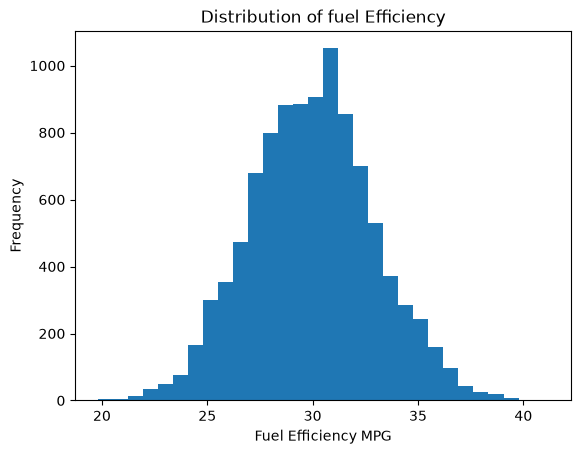

In [5]:
plt.hist(df.fuel_efficiency_mpg, bins = 30)
plt.xlabel("Fuel Efficiency MPG")
plt.ylabel("Frequency")
plt.title("Distribution of fuel Efficiency")
plt.show()

# Q.1 Missing values

In [6]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [7]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [8]:
# Horsepower column contains the missing values. ie 877 missing values.

# 2. Median for Horsepower

In [9]:
df.horsepower.median()

np.float64(254.0)

## Prepare and split the dataset

In [10]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

# Q.3 Missing value imputation

In [11]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year"
]

target = "fuel_efficiency_mpg"

In [12]:
def prepare_X(df, fill_value):
    df = df[features].copy()
    df = df.fillna(fill_value)
    return df.values

In [14]:
# Option A — Fill missing horsepower with 0
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

y_train = df_train[target].values
y_val = df_val[target].values

In [15]:
def train_linear_regression(X, y):
    X = np.column_stack([np.ones(X.shape[0]), X])

    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)

    w = XTX_inv @ X.T @ y

    return w

In [16]:
w = train_linear_regression(X_train, y_train)

In [17]:
def predict(X, w):
    X = np.column_stack([np.ones(X.shape[0]), X])
    return X @ w

In [19]:
y_pred = predict(X_val, w)
y_pred

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

In [20]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [21]:
score_zero = rmse(y_val, y_pred)

round(score_zero, 3)

np.float64(2.205)

In [23]:
# Option B — Fill missing values with the mean
# Calculating mean using training data only
horsepower_mean = df_train["horsepower"].mean()

print("Training horsepower mean:", horsepower_mean)

Training horsepower mean: 254.46338337605272


In [24]:
X_train_mean = df_train[features].copy()
X_val_mean = df_val[features].copy()

X_train_mean = X_train_mean.fillna(horsepower_mean)
X_val_mean = X_val_mean.fillna(horsepower_mean)

X_train_mean = X_train_mean.values
X_val_mean = X_val_mean.values

In [25]:
w_mean = train_linear_regression(X_train_mean, y_train)

y_pred_mean = predict(X_val_mean, w_mean)

score_mean = rmse(y_val, y_pred_mean)

round(score_mean, 3)

np.float64(2.202)

In [ ]:
# Q3 answer: With mean becasue rmse decreased when trained with mean imputted

# Q.4  Finding the best regularization parameter

In [26]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

In [28]:
def train_linear_regression_reg(X, y, r):
    X = np.column_stack([np.ones(X.shape[0]), X])

    XTX = X.T @ X
    reg = r * np.eye(XTX.shape[0])
    reg[0, 0] = 0

    XTX = XTX + reg

    return np.linalg.solve(XTX, X.T @ y)

In [29]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_values:
    w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = predict(X_val, w)
    score = rmse(y_val, y_pred)

    print(r, round(score, 4))

0 2.2053
0.01 2.2053
0.1 2.2053
1 2.2053
5 2.2053
10 2.2053
100 2.2053


In [ ]:
# Q4 answer: 0 becasue multiple rmse have same values so we choose the smallest r from the list.ie 0

# Question 5

In [36]:
scores = []

for seed in range(10):

    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()

    # Fill missing values with 0
    X_train = df_train[features].fillna(0).values
    X_val = df_val[features].fillna(0).values

    y_train = df_train[target].values
    y_val = df_val[target].values

    # Train
    w = train_linear_regression(X_train, y_train)

    # Predict
    y_pred = predict(X_val, w)

    # RMSE
    score = rmse(y_val, y_pred)
    scores.append(score)

print(scores)
print("std =", np.std(scores))
print("rounded =", round(np.std(scores), 3))

[np.float64(2.2392041430461265), np.float64(2.202112821083884), np.float64(2.1634197787530947), np.float64(2.2043588768539215), np.float64(2.2018800943311554), np.float64(2.2457851509085134), np.float64(2.2697212079524043), np.float64(2.190794599933443), np.float64(2.216611201686444), np.float64(2.207036592817896)]
std = 0.02878127407819125
rounded = 0.029


In [ ]:
# Q5. answer 0.029

# Q.6 Using seed 9

In [38]:
# Split using seed 9

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]


# Combine train and validation

df_train_full = pd.concat([df_train, df_val])


# Prepare features

X_train_full = df_train_full[features].fillna(0).values
X_test = df_test[features].fillna(0).values

y_train_full = df_train_full[target].values
y_test = df_test[target].values


# Train regularized model

w = train_linear_regression_reg(
    X_train_full,
    y_train_full,
    r=0.001
)


# Predict

y_pred = predict(X_test, w)


# RMSE

score = rmse(y_test, y_pred)

print("Test RMSE:", score)
print("Rounded:", round(score, 3))

Test RMSE: 2.2357747028137953
Rounded: 2.236
